# 数据预处理

# 主题：基于 MCD 马氏距离的多变量异常值检测

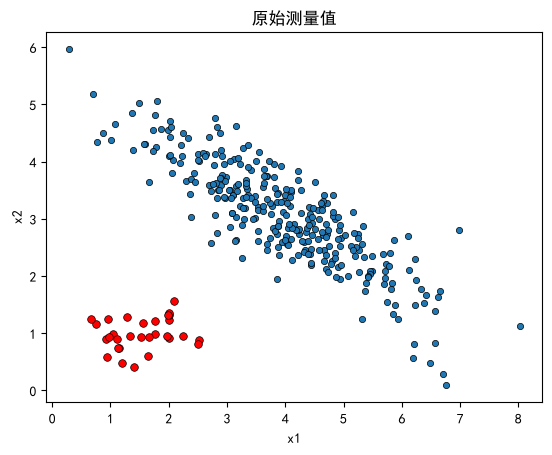

In [2]:
# 读取数据
import numpy as np
data_2Doutlier = np.loadtxt('complex2D_outlier.csv', delimiter=',')

# 绘图
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'WenQuanYi Micro Hei']
plt.plot(data_2Doutlier[:-30,0], data_2Doutlier[:-30,1], '.', markeredgecolor='k', markeredgewidth=0.5, ms=9)
plt.plot(data_2Doutlier[-30:,0], data_2Doutlier[-30:,1], '.r', markeredgecolor='k', markeredgewidth=0.5, ms=11)
plt.xlabel('x1'), plt.ylabel('x2')
plt.title('原始测量值')
plt.show()

In [3]:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                    非稳健马氏距离
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [3]:
# 计算马氏距离
from sklearn.covariance import EmpiricalCovariance

emp_cov = EmpiricalCovariance().fit(data_2Doutlier)
MD_emp_cov = emp_cov.mahalanobis(data_2Doutlier)

In [4]:
# 通过立方根变换将马氏距离转换为近似正态分布
MD_emp_cov_cubeRoot = np.power(MD_emp_cov, 0.333)

In [6]:
# 计算 Hampel 标识符边界
from scipy import stats

median = np.median(MD_emp_cov_cubeRoot)
sigma_MAD = stats.median_abs_deviation(MD_emp_cov_cubeRoot)

upperBound_MD_emp_cov = np.power(median+3*sigma_MAD, 3)
lowerBound_MD_emp_cov = np.power(median-3*sigma_MAD, 3)

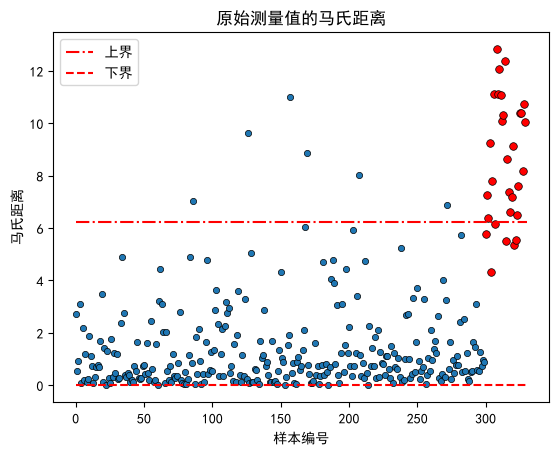

In [7]:
# 绘制马氏距离及边界
plt.figure()
plt.plot(MD_emp_cov[:-30], '.', markeredgecolor='k', markeredgewidth=0.5, ms=9)
plt.plot(np.arange(300,330), MD_emp_cov[-30:], '.r', markeredgecolor='k', markeredgewidth=0.5, ms=11)

plt.hlines(upperBound_MD_emp_cov, 0, 330, colors='r', linestyles='dashdot', label='上界') 
plt.hlines(lowerBound_MD_emp_cov, 0, 330, colors='r', linestyles='dashed', label='下界') 

plt.xlabel('样本编号'), plt.ylabel('马氏距离')
plt.title('原始测量值的马氏距离')
plt.legend(loc='upper left')
plt.show()

In [8]:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                    基于 MCD 的稳健马氏距离
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
from sklearn.covariance import MinCovDet

MCD_cov = MinCovDet().fit(data_2Doutlier)
MD_MCD = MCD_cov.mahalanobis(data_2Doutlier)

In [9]:
# 通过立方根变换将马氏距离转换为近似正态分布
MD_MCD_cubeRoot = np.power(MD_MCD, 0.333)

In [11]:
# 计算 Hampel 标识符边界
from scipy import stats

median = np.median(MD_MCD_cubeRoot)
sigma_MAD = stats.median_abs_deviation(MD_MCD_cubeRoot)

upperBound_MD_emp_cov = np.power(median+3*sigma_MAD, 3)
lowerBound_MD_emp_cov = np.power(median-3*sigma_MAD, 3)

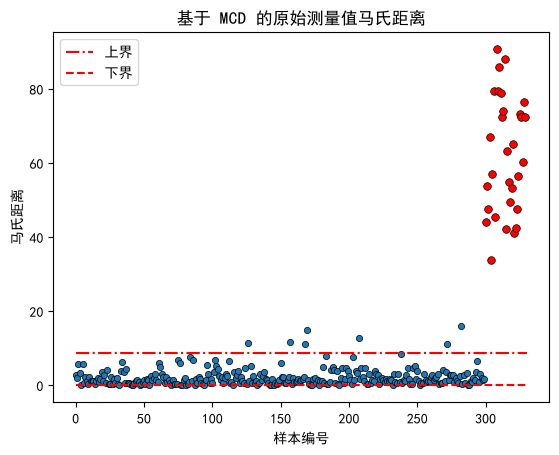

In [12]:
# 绘制马氏距离及边界
plt.figure()
plt.plot(MD_MCD[:-30], '.', markeredgecolor='k', markeredgewidth=0.5, ms=9)
plt.plot(np.arange(300,330), MD_MCD[-30:], '.r', markeredgecolor='k', markeredgewidth=0.5, ms=11)

plt.hlines(upperBound_MD_emp_cov, 0, 330, colors='r', linestyles='dashdot', label='上界') 
plt.hlines(lowerBound_MD_emp_cov, 0, 330, colors='r', linestyles='dashed', label='下界') 

plt.xlabel('样本编号'), plt.ylabel('马氏距离')
plt.title('基于 MCD 的原始测量值马氏距离')
plt.legend(loc='upper left')
plt.show()